In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 데이터 불러오기 및 인코딩 확인
# ==========================================
file_path = 'input.csv'  

try:
    df = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    try:
        df = pd.read_csv(file_path, encoding='utf-8-sig')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='cp949', errors='ignore')

print(f"데이터 로드 완료! 총 행 수: {df.shape[0]}개, 컬럼 수: {df.shape[1]}개")


# ==========================================
# 2. 날짜 데이터 가공 및 요일 원핫 인코딩
# ==========================================
df['일자'] = pd.to_datetime(df['일자'])

# 요일 번호 추출 후 원핫 인코딩 생성 (요일_0 ~ 요일_6)
df['요일_num'] = df['일자'].dt.dayofweek
df = pd.get_dummies(df, columns=['요일_num'], prefix='요일', dtype=int)


# ==========================================
# 3. 휴일구분 이진화 (0: 평일, 1: 휴일)
# ==========================================
def convert_holiday(val):
    if val == '평일':
        return 0
    else:
        return 1

df['is_holiday'] = df['휴일구분'].apply(convert_holiday)


# ==========================================
# 4. 지정된 기상정보 데이터 정제
# ==========================================
weather_features = ['평균기온', '일강수량', '평균상대습도']

for col in weather_features:
    # '-' 문자를 NaN으로 치환 후 숫자로 변환
    df[col] = df[col].replace('-', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # 결측치는 중앙값으로 채우기
    df[col] = df[col].fillna(df[col].median())


# ==========================================
# 5. 불필요한 칼럼 드롭 및 최종 피처(X) / 타겟(y) 정의
# ==========================================
# 원핫 인코딩된 요일 컬럼들 자동 추출
day_columns = [col for col in df.columns if col.startswith('요일_')]

# 모델에 투입할 최종 피처 리스트
features = day_columns + ['is_holiday'] + weather_features
target = '전체건수'

# 사용하지 않는 나머지 칼럼은 모두 버리고 필요한 칼럼만 남기기
final_columns = features + [target]
df_cleaned = df[final_columns].copy()

print("\n--- [불필요한 칼럼 제거 후 남은 최종 칼럼 목록] ---")
print(df_cleaned.columns.tolist())

X = df_cleaned[features]
y = df_cleaned[target]


# ==========================================
# 6. 머신러닝 학습/테스트 데이터 분할 (Train/Test Split)
# ==========================================
# 시계열 데이터이므로 섞지 않음 (shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"\n학습용 데이터 크기 (X_train): {X_train.shape}")
print(f"테스트용 데이터 크기 (X_test): {X_test.shape}")


# ==========================================
# 7. 데이터 스케일링 (StandardScaler)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n모든 전처리와 불필요한 칼럼 정리가 완벽하게 완료되었습니다!")

데이터 로드 완료! 총 행 수: 1277개, 컬럼 수: 17개

--- [불필요한 칼럼 제거 후 남은 최종 칼럼 목록] ---
['요일_0', '요일_1', '요일_2', '요일_3', '요일_4', '요일_5', '요일_6', 'is_holiday', '평균기온', '일강수량', '평균상대습도', '전체건수']

학습용 데이터 크기 (X_train): (1021, 11)
테스트용 데이터 크기 (X_test): (256, 11)

모든 전처리와 불필요한 칼럼 정리가 완벽하게 완료되었습니다!


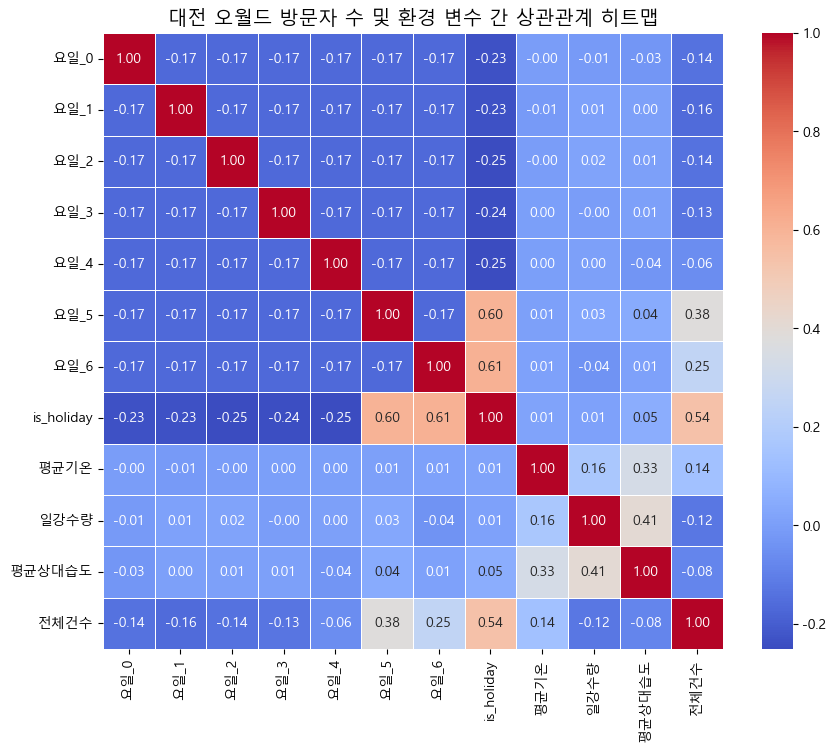


--- [전체건수와의 상관관계 순위] ---
전체건수          1.000000
is_holiday    0.542809
요일_5          0.379666
요일_6          0.254265
평균기온          0.137197
요일_4         -0.055761
평균상대습도       -0.083603
일강수량         -0.124660
요일_3         -0.130896
요일_2         -0.141989
요일_0         -0.142676
요일_1         -0.162493
Name: 전체건수, dtype: float64


C:\Users\skdpa\AppData\Local\Temp\ipykernel_19508\3785340725.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='is_holiday', y='전체건수', ax=axes[2], palette='Set2')
C:\Users\skdpa\AppData\Local\Temp\ipykernel_19508\3785340725.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['평일 (0)', '휴일 (1)'])


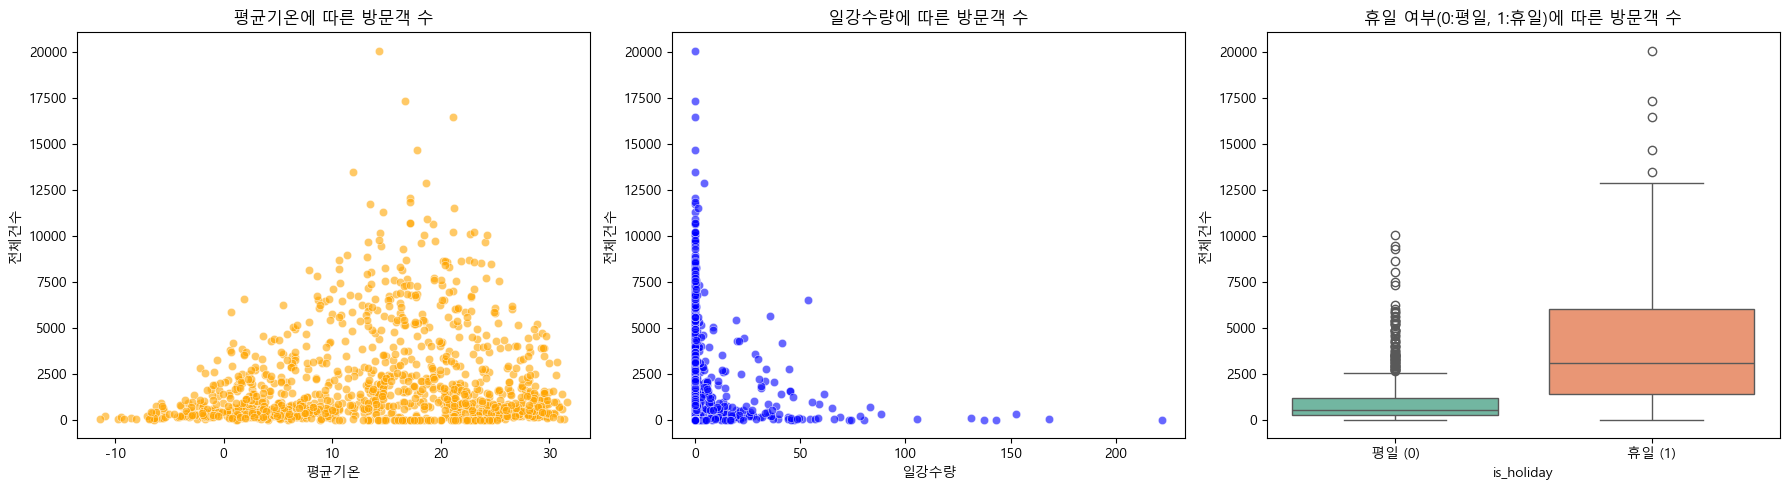

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 깨짐 방지 (시스템 환경에 따라 설정)
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows의 경우
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac의 경우
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 상관관계 계수 계산 및 히트맵 시각화
# ==========================================
plt.figure(figsize=(10, 8))

# df_cleaned 데이터프레임의 상관관계를 구합니다.
corr_matrix = df_cleaned.corr()

# 히트맵 그리기
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('대전 오월드 방문자 수 및 환경 변수 간 상관관계 히트맵', fontsize=14)
plt.show()

# '전체건수'와 가장 상관관계가 높은 순서대로 출력
print("\n--- [전체건수와의 상관관계 순위] ---")
print(corr_matrix['전체건수'].sort_values(ascending=False))


# ==========================================
# 2. 주요 변수와 방문객 수 관계 시각화 (서브플롯)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 평균기온 vs 전체건수 (산점도)
sns.scatterplot(data=df_cleaned, x='평균기온', y='전체건수', alpha=0.6, ax=axes[0], color='orange')
axes[0].set_title('평균기온에 따른 방문객 수')

# 2) 일강수량 vs 전체건수 (산점도)
sns.scatterplot(data=df_cleaned, x='일강수량', y='전체건수', alpha=0.6, ax=axes[1], color='blue')
axes[1].set_title('일강수량에 따른 방문객 수')

# 3) 휴일여부(is_holiday) vs 전체건수 (박스플롯)
sns.boxplot(data=df_cleaned, x='is_holiday', y='전체건수', ax=axes[2], palette='Set2')
axes[2].set_title('휴일 여부(0:평일, 1:휴일)에 따른 방문객 수')
axes[2].set_xticklabels(['평일 (0)', '휴일 (1)'])

plt.tight_layout()
plt.show()